In [2]:
pip install pandas numpy matplotlib seaborn nltk textblob scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

expenses = pd.read_csv("datasets/expenses.csv")

# expenses.head()
print(expenses['Date'])
print(expenses['Date'].dtype)

0       2025-02-25
1       2025-02-25
2       2025-02-25
3       2025-02-25
4       2025-02-25
           ...    
1995    2025-02-25
1996    2025-02-25
1997    2025-02-25
1998    2025-02-25
1999    2025-02-25
Name: Date, Length: 2000, dtype: object
object


In [4]:
category_summary = expenses.groupby('Category')['Amount'].agg(['sum', 'mean']).reset_index()

category_summary.head()
# expenses.head()


,Category,sum,mean
0,Ambulance Call,-675590,-1723.443878
1,Equipment Maintenance,-240142,-597.368159
2,Rental,50210,122.165450
3,Staff Salary,-2503121,-6484.769430
4,Ticket Sale,594790,1454.254279


   Season      sum         mean
0  Summer -1595223 -1608.087702
1  Winter -1178630 -1169.275794


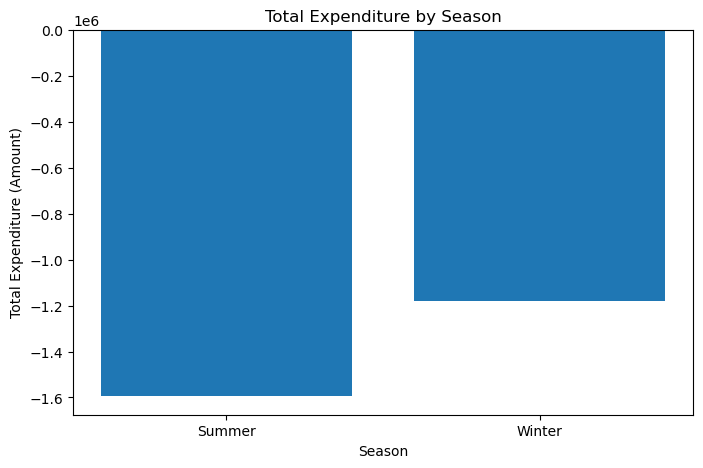

,Transaction_ID,Transaction_Type,Category,Amount,Date,Season,Weather,Customer_ID,Incident_ID
0,0,Revenue,Ticket Sale,3500,2025-02-25,Winter,Foggy,1415.0,NaN
1,1,Revenue,Ticket Sale,640,2025-02-25,Winter,Windy,5095.0,NaN
2,2,Expense,Ambulance Call,-1490,2025-02-25,Winter,Foggy,NaN,96.0
3,3,Expense,Equipment Maintenance,-730,2025-02-25,Winter,Sunny,NaN,NaN
4,4,Expense,Staff Salary,-4238,2025-02-25,Summer,Sunny,NaN,NaN


In [5]:
seasonal_summary = expenses.groupby('Season')['Amount'].agg(['sum', 'mean']).reset_index()

print(seasonal_summary)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(seasonal_summary['Season'], seasonal_summary['sum'])
plt.title('Total Expenditure by Season')
plt.xlabel('Season')
plt.ylabel('Total Expenditure (Amount)')
plt.show()

expenses.head()

In [6]:
fixed_cost_categories = ['Salaries', 'Rent', 'Utilities']

expenses['Cost_Type'] = expenses['Category'].apply(lambda x: 'Fixed' if x in fixed_cost_categories else 'Variable')

cost_type_summary = expenses.groupby('Cost_Type')['Amount'].agg(['sum', 'mean']).reset_index()

cost_type_summary

expenses.head()

,Transaction_ID,Transaction_Type,Category,Amount,Date,Season,Weather,Customer_ID,Incident_ID,Cost_Type
0,0,Revenue,Ticket Sale,3500,2025-02-25,Winter,Foggy,1415.0,NaN,Variable
1,1,Revenue,Ticket Sale,640,2025-02-25,Winter,Windy,5095.0,NaN,Variable
2,2,Expense,Ambulance Call,-1490,2025-02-25,Winter,Foggy,NaN,96.0,Variable
3,3,Expense,Equipment Maintenance,-730,2025-02-25,Winter,Sunny,NaN,NaN,Variable
4,4,Expense,Staff Salary,-4238,2025-02-25,Summer,Sunny,NaN,NaN,Variable


In [7]:
transaction_summary = expenses.groupby('Transaction_Type')['Amount'].sum().reset_index()

print(transaction_summary)

total_revenue = transaction_summary.loc[transaction_summary['Transaction_Type'] == 'Revenue', 'Amount'].values[0]
total_expense = transaction_summary.loc[transaction_summary['Transaction_Type'] == 'Expense', 'Amount'].values[0]

profit_margin = ((total_revenue + total_expense) / total_revenue) * 100

print("Overall Profit Margin: {:.2f}%".format(profit_margin))

expenses.head()

  Transaction_Type   Amount
0          Expense -3418853
1          Revenue   645000
Overall Profit Margin: -430.05%


,Transaction_ID,Transaction_Type,Category,Amount,Date,Season,Weather,Customer_ID,Incident_ID,Cost_Type
0,0,Revenue,Ticket Sale,3500,2025-02-25,Winter,Foggy,1415.0,NaN,Variable
1,1,Revenue,Ticket Sale,640,2025-02-25,Winter,Windy,5095.0,NaN,Variable
2,2,Expense,Ambulance Call,-1490,2025-02-25,Winter,Foggy,NaN,96.0,Variable
3,3,Expense,Equipment Maintenance,-730,2025-02-25,Winter,Sunny,NaN,NaN,Variable
4,4,Expense,Staff Salary,-4238,2025-02-25,Summer,Sunny,NaN,NaN,Variable


In [8]:
seasonal_pivot = expenses.groupby(['Season', 'Transaction_Type'])['Amount'].sum().unstack()

seasonal_pivot['Profit_Margin'] = ((seasonal_pivot['Revenue'] - seasonal_pivot['Expense']) / seasonal_pivot['Revenue']) * 100

print("Seasonal Profitability:")
print(seasonal_pivot)

expenses.head()

Seasonal Profitability:
Transaction_Type  Expense  Revenue  Profit_Margin
Season                                           
Summer           -1745053   149830    1264.688647
Winter           -1673800   495170     438.025325


,Transaction_ID,Transaction_Type,Category,Amount,Date,Season,Weather,Customer_ID,Incident_ID,Cost_Type
0,0,Revenue,Ticket Sale,3500,2025-02-25,Winter,Foggy,1415.0,NaN,Variable
1,1,Revenue,Ticket Sale,640,2025-02-25,Winter,Windy,5095.0,NaN,Variable
2,2,Expense,Ambulance Call,-1490,2025-02-25,Winter,Foggy,NaN,96.0,Variable
3,3,Expense,Equipment Maintenance,-730,2025-02-25,Winter,Sunny,NaN,NaN,Variable
4,4,Expense,Staff Salary,-4238,2025-02-25,Summer,Sunny,NaN,NaN,Variable


First 5 rows of the dataset:
   Transaction_ID Transaction_Type               Category  Amount        Date  \
0               0          Revenue            Ticket Sale    3500  2025-02-25   
1               1          Revenue            Ticket Sale     640  2025-02-25   
2               2          Expense         Ambulance Call   -1490  2025-02-25   
3               3          Expense  Equipment Maintenance    -730  2025-02-25   
4               4          Expense           Staff Salary   -4238  2025-02-25   

   Season Weather  Customer_ID  Incident_ID Cost_Type  
0  Winter   Foggy       1415.0          NaN  Variable  
1  Winter   Windy       5095.0          NaN  Variable  
2  Winter   Foggy          NaN         96.0  Variable  
3  Winter   Sunny          NaN          NaN  Variable  
4  Summer   Sunny          NaN          NaN  Variable  
Trends over Transaction ID bins:
   Transaction_Bin  Amount
0                0 -187403
1              100  -90910
2              200 -185871
3      

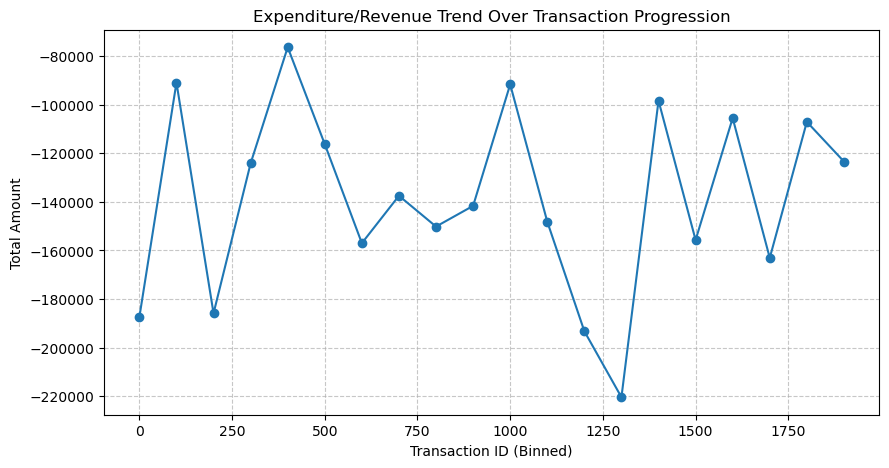

In [9]:
expenses.columns = expenses.columns.str.strip()

print("First 5 rows of the dataset:")
print(expenses.head())

expenses = expenses.sort_values(by="Transaction_ID")

expenses["Transaction_Bin"] = expenses["Transaction_ID"] // 100 * 100

transaction_trends = expenses.groupby("Transaction_Bin")["Amount"].sum().reset_index()

print("Trends over Transaction ID bins:")
print(transaction_trends.head())

plt.figure(figsize=(10, 5))
plt.plot(transaction_trends["Transaction_Bin"], transaction_trends["Amount"], marker='o', linestyle='-')

plt.title('Expenditure/Revenue Trend Over Transaction Progression')
plt.xlabel('Transaction ID (Binned)')
plt.ylabel('Total Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [10]:
print(expenses['Date'])
print(expenses['Date'].dtype)

0       2025-02-25
1       2025-02-25
2       2025-02-25
3       2025-02-25
4       2025-02-25
           ...    
1995    2025-02-25
1996    2025-02-25
1997    2025-02-25
1998    2025-02-25
1999    2025-02-25
Name: Date, Length: 2000, dtype: object
object


In [11]:
if 'Incident_ID' in expenses.columns:

    incident_cost_summary = expenses.groupby('Incident_ID')['Amount'].mean().reset_index()
    print("Average Expenditure per Incident (first few records):")
    print(incident_cost_summary.head())
else:
    print("No Incident_ID column found in the dataset; skipping cost per incident analysis.")



Average Expenditure per Incident (first few records):
   Incident_ID  Amount
0          2.0 -1644.0
1          4.0 -1444.5
2         12.0 -1455.0
3         16.0 -1779.5
4         20.0 -1469.6
